# This script computes the metrics used in the final text and reporting recipe

In [18]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os.path as path
import utils
import matplotlib.pyplot as plt
from collections import Counter

In [19]:
# load all files previously computed
lau_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "drought_days_lau.geojson"))
nuts3_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "nuts3_stats.geojson"))
country_df = pd.read_json(path.join(utils.out_data_dir, "country_stats.geojson"))

# Most drought-stricken countries
This outputs all analyzed countries in order, based on how many drought days they experience on average per year.

In [20]:
for i, cntr in enumerate(country_df.sort_values(by="median_drought_days", ascending=False)["NAME_ENGL"].values):
    print(i+1, cntr)

1 Albania
2 Serbia
3 Poland
4 Liechtenstein
5 North Macedonia
6 Bulgaria
7 Greece
8 Lithuania
9 Switzerland
10 Romania
11 France
12 Croatia
13 Czechia
14 Slovenia
15 Slovakia
16 Spain
17 Italy
18 Cyprus
19 Luxembourg
20 United Kingdom
21 Germany
22 Hungary
23 Belgium
24 Netherlands
25 Ireland
26 Austria
27 Malta
28 Portugal
29 Denmark
30 Sweden
31 Finland
32 Iceland
33 Estonia
34 Norway
35 Latvia


In [38]:
country_df.sort_values(by="max_drought_days")[:5][["NAME_ENGL", "median_drought_days", "max_drought_days"]]

,NAME_ENGL,median_drought_days,max_drought_days
NO,Norway,34.11,69.70
FI,Finland,40.98,104.12
AT,Austria,56.52,110.29
SE,Sweden,44.94,119.68
IS,Iceland,35.93,148.81


Looking at the countries with the lowest "max_drought_days" value:
--> all countries in Europe have faced drought in the observed timeframe.

# Europe-wide statistics
This section splits the nuts3-dataset along a threshold for median and maximum drought days. From this it computes a portion of surface area

In [21]:
drought_days_median_50_mask = nuts3_df["median_drought_days"] > 50
dry_nuts3_df = nuts3_df[drought_days_median_50_mask]
wet_nuts3_df = nuts3_df[~drought_days_median_50_mask]
dryland_km2, wetland_km2 = dry_nuts3_df["area_km2"].sum(), wet_nuts3_df["area_km2"].sum()
dryland_km2 / (dryland_km2+wetland_km2)

np.float64(0.6541255404617256)

--> almost two thirds of the EEA+UK area experiences on average more than 50 days of drought warnings per year.

In [22]:
drought_days_median_100_mask = nuts3_df["median_drought_days"] > 100
dry_nuts3_df = nuts3_df[drought_days_median_100_mask]
wet_nuts3_df = nuts3_df[~drought_days_median_100_mask]
dryland_km2, wetland_km2 = dry_nuts3_df["area_km2"].sum(), wet_nuts3_df["area_km2"].sum()
dryland_km2 / (dryland_km2+wetland_km2)

np.float64(0.11943094078060766)

--> Over 10% of the EEA+UK area experiences on average more than 100 days of drought warnings per year.

In [23]:
drought_days_max_183_mask = nuts3_df["max_drought_days"] >= 183
dry_nuts3_df = nuts3_df[drought_days_max_183_mask]
wet_nuts3_df = nuts3_df[~drought_days_max_183_mask]
dryland_km2, wetland_km2 = dry_nuts3_df["area_km2"].sum(), wet_nuts3_df["area_km2"].sum()
dryland_km2 / (dryland_km2+wetland_km2)

np.float64(0.6648711964996835)

--> Two thirds of all regions in EEA+UK have experienced a severe drought year since 2012, in which a drought warning was issued for over 183 Days (half a year).

# NUTS-3-regions with the highest median number of drought days

In [34]:
nuts3_df.sort_values(by="median_drought_days", ascending=False)[:10][["nuts_id", "cntr_code", "name_latn", "median_drought_days", "max_drought_days"]]

,nuts_id,cntr_code,name_latn,median_drought_days,max_drought_days
8,AL032,AL,Fier,199.85,334.84
1110,PL923,PL,Płocki,178.71,345.02
1099,PL822,PL,Przemyski,175.58,253.82
128,CH032,CH,Basel-Landschaft,167.22,281.20
670,ES611,ES,Almería,165.54,307.81
1279,UKE32,UK,Sheffield,165.23,279.97
11,AL035,AL,Vlorë,162.00,267.75
609,EL542,EL,Thesprotia,159.92,309.65
983,MK005,MK,Pelagoniski,156.90,306.41
607,EL533,EL,Florina,156.30,273.65


In [35]:
lau_df.sort_values(by="median_drought_days", ascending=False)[:10][["GISCO_ID", "CNTR_CODE", "LAU_NAME", "median_drought_days", "max_drought_days"]]

,GISCO_ID,CNTR_CODE,LAU_NAME,median_drought_days,max_drought_days
701,ES_18056,ES,Cúllar,280.94,357.73
18662,EL_41010301,EL,Κοινότητα Αγίας Τριάδας,275.00,340.00
18670,EL_41010309,EL,Κοινότητα Πουλλακίδας,275.00,340.00
2237,ES_18029,ES,Benamaurel,270.95,359.75
2742,ES_18187,ES,Villanueva de las Torres,263.94,360.00
18665,EL_41010304,EL,Κοινότητα Αργολικού,262.90,349.54
18669,EL_41010308,EL,Κοινότητα Παναρίτη,252.42,346.28
707,ES_18064,ES,Dehesas de Guadix,250.94,352.96
15048,EL_10020117,EL,Κοινότητα Τσάκων,248.38,314.28
18666,EL_41010305,EL,Κοινότητα Ηραίου,246.38,348.17


In [26]:

avg_drought_days_gt_100 = len(lau_df[lau_df["median_drought_days"] > 100])
print(f"{avg_drought_days_gt_100} of {len(lau_df)} LAUs ({100* avg_drought_days_gt_100 / len(lau_df):.2f}%) experience more than 100 drought days per year.")

19362 of 99114 LAUs (19.54%) experience more than 100 drought days per year.


In [27]:
max_drought_days_gt_200 = len(lau_df[lau_df["max_drought_days"] > 200])
print(f"{max_drought_days_gt_200} of {len(lau_df)} LAUs ({100* max_drought_days_gt_200 / len(lau_df):.2f}%) experienced at least one year between 2012 and 2025 with over 200 drought days.")

print("most frequent 'worst year' at LAU-scale:")
print(lau_df["max_drought_days_year"].value_counts()[:5])

82779 of 99114 LAUs (83.52%) experienced at least one year between 2012 and 2025 with over 200 drought days.
most frequent 'worst year' at LAU-scale:
max_drought_days_year
2019    20158
2022    19760
2017    13365
2012    13045
2018     7216
Name: count, dtype: int64


In [28]:
nuts3_df["cropland_km2_by_type"] = nuts3_df["cropland_km2_by_type"].apply(lambda x: eval(x) if isinstance(x, str) else {})
high_drought_df = nuts3_df[nuts3_df["median_drought_days"] > 100]
low_drought_df = nuts3_df[nuts3_df["median_drought_days"] <= 100]

In [29]:
low_drought_crops = sum([Counter(dct) for dct in low_drought_df["cropland_km2_by_type"].values], Counter())
high_drought_crops= sum([Counter(dct) for dct in high_drought_df["cropland_km2_by_type"].values], Counter())

In [30]:
sum(low_drought_crops.values()) + sum(high_drought_crops.values())

0

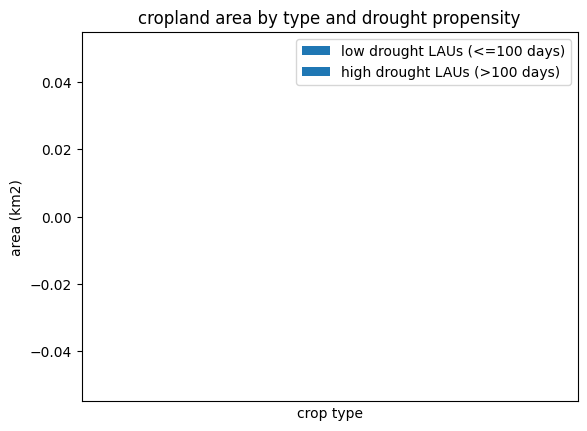

In [31]:
# 1. Align keys (intersection is safest)
keys = sorted(set(low_drought_crops) & set(high_drought_crops))

# 2. Compute ratio (avoid division by zero)
def safe_ratio(k):
    return low_drought_crops[k] / high_drought_crops[k] if high_drought_crops[k] != 0 else float('inf')

# 3. Sort keys by ratio
keys_sorted = sorted(keys, key=safe_ratio)

# 4. Extract values in sorted order
vals1 = np.array([low_drought_crops[k] for k in keys_sorted])
vals2 = np.array([high_drought_crops[k] for k in keys_sorted])

# 5. Plot stacked bar chart
x = np.arange(len(keys_sorted))

plt.figure()
plt.bar(x, vals1, label='low drought LAUs (<=100 days)')
plt.bar(x, vals2, bottom=vals1, label='high drought LAUs (>100 days)')

plt.xticks(x, keys_sorted, rotation=45, ha="right")
plt.legend()
plt.xlabel('crop type')
plt.ylabel('area (km2)')
plt.title('cropland area by type and drought propensity')

plt.show()